<a href="https://colab.research.google.com/github/kyaadevi/Praktkum-Sturktur-Data/blob/main/Praktikum_Ke_10_Djikstra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalasi Library

In [ ]:
!pip install networkx matplotlib

Struktur Data Graf dan Algoritma

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [ (0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph[current_node].item():
      distance = current_distance + weight
      if distance < distances[neighbor]:
        distances[neighbor] = distance
        previous[neighbor] = current_node
        heapq.heapppush(queue, (distance, neighbor))

  return distances, previous

Fungsi untuk Merekonstruksi Jalur

In [ ]:
daf get_path(previous, target):
  path = []
  while target is not None:
    path.insert(0, target)
    target = previous[target]
  return path

Visualisasi dengan Networok dan Matplotlib

In [ ]:
def visualize_graph(graph, path=None):
  G = nx.DiGraph()

  for node in graph:
    for neighbor, weight in graph[node].items():
      G.add_egde(node, neighbor, weight=weight)

  pos = nx.spring_layout(G)
  edge_labels = nx.get_edge_attributes(G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)

  # Garis tebal untuk jalur terpendek
  if path and len(path)>1:
    path_edges = list(zip(path, path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

  plt.tittle("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()

Penggunaan Lengkap

Jarak dari A ke Z: 14
Jalur: A-->B-->D-->E-->Z


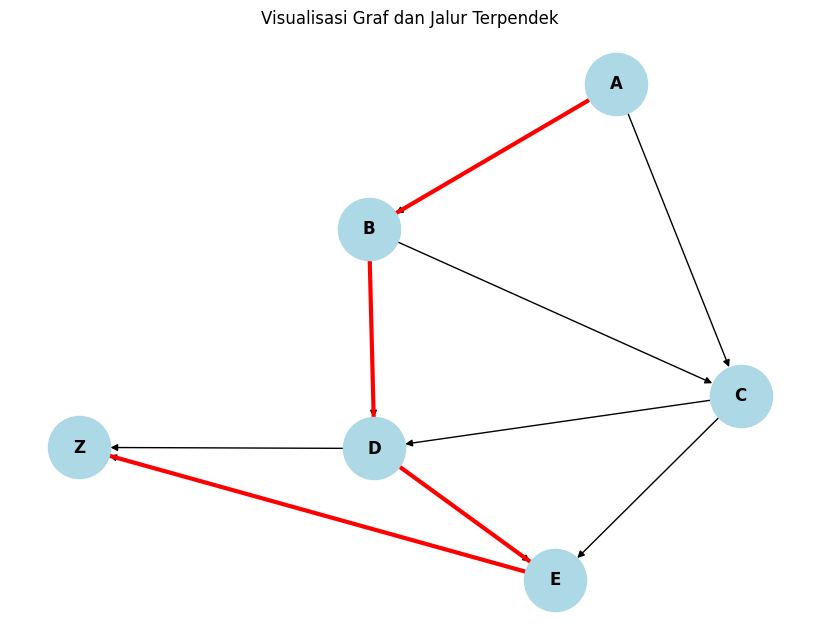

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [ (0, start)]

  while queue:
    current_distance, current_node = heapq.heappop(queue)

    for neighbor, weight in graph[current_node].items():
      distance = current_distance + weight
      if distance < distances[neighbor]:
        distances[neighbor] = distance
        previous[neighbor] = current_node
        heapq.heappush(queue, (distance, neighbor))

  return distances, previous

def get_path(previous, target):
    path = []
    while target is not None:
      path.insert(0, target)
      target = previous[target]
    return path

def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
      for neighbor, weight in graph[node].items():
        G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)

    # Garis tebal untuk jalur terpendek
    if path and len(path)>1:
      path_edges = list(zip(path, path[1:]))
      nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# Definisi Graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekomendasi Jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {'-->'.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)


TUGAS


Tambahkan simpul baru dan lihat bagaimana jalur terpendek berubah

Jarak dari A ke Z: 8
Jalur: A-->C-->X-->Y-->Z


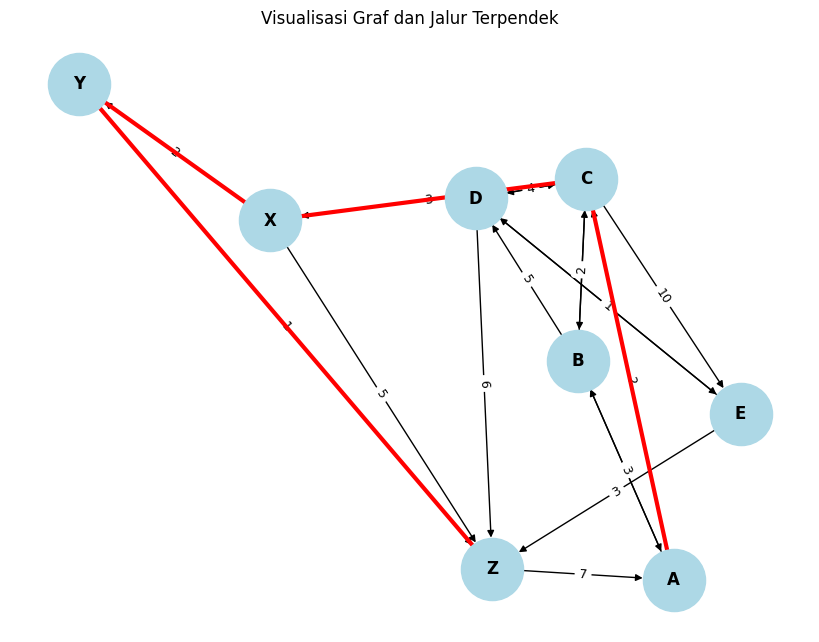

In [ ]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# ========== FUNGSI DIJKSTRA ==========
def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

# ========== FUNGSI MENGAMBIL JALUR ==========
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous[target]
    return path

# ========== POIN 3: FUNGSI VISUALISASI DENGAN PILIHAN LAYOUT ==========
def visualize_graph(graph, path=None, layout='spring'):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    # Pilihan layout: spring, circular, atau kamada_kawai
    if layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.spring_layout(G)

    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_weight='bold', arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

    # Garis merah untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# ========== POIN 1: GRAF DENGAN SIKLUS ==========
# POIN 2: DITAMBAH SIMPUL X DAN Y
graph_with_cycle = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5, 'A': 3},       # ada edge B->A (membuat siklus)
    'C': {'D': 8, 'E': 10, 'B': 2, 'X': 3}, # ada edge C->B dan cabang ke X
    'D': {'E': 2, 'Z': 6, 'C': 4},       # ada edge D->C
    'E': {'Z': 3, 'D': 1},               # ada edge E->D
    'Z': {'A': 7},                       # ada edge Z->A
    'X': {'Y': 2, 'Z': 5},               # simpul baru X
    'Y': {'Z': 1}                        # simpul baru Y
}

# ========== MENJALANKAN DIJKSTRA ==========
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph_with_cycle, start_node)

# ========== MENAMPILKAN HASIL ==========
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {'-->'.join(shortest_path)}")

# ========== POIN 3: VISUALISASI (pake layout spring) ==========
# Bisa diganti layout='circular' atau layout='kamada_kawai'
visualize_graph(graph_with_cycle, path=shortest_path, layout='spring')